## Imports

In [1]:
# 1
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, cophenet
from scipy.spatial.distance import pdist
from sklearn.neighbors import NearestNeighbors

np.random.seed(42)
warnings.filterwarnings("ignore")

def save_plot(fig, filename, directory="plots", dpi=300):
    os.makedirs(directory, exist_ok=True)
    path = os.path.join(directory, filename)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")

## Dataset Loading

In [ ]:
# 2
data = load_wine()
X = data.data
feature_names = data.feature_names

print("Shape:", X.shape)

Shape: (178, 13)


## Feature-wise Statistical Summary

In [ ]:
# 3
means = np.mean(X, axis=0)
stds = np.std(X, axis=0)

stats_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean": means,
    "Std": stds
})

stats_df

,Feature,Mean,Std
0,alcohol,13.000618,0.809543
1,malic_acid,2.336348,1.114004
2,ash,2.366517,0.273572
3,alcalinity_of_ash,19.494944,3.330170
4,magnesium,99.741573,14.242308
5,total_phenols,2.295112,0.624091
6,flavanoids,2.029270,0.996049
7,nonflavanoid_phenols,0.361854,0.124103
8,proanthocyanins,1.590899,0.570749
9,color_intensity,5.058090,2.311765


## Missing Value Verification

In [ ]:
# 4
missing = np.isnan(X).sum()
print("Total missing values:", missing)

Total missing values: 0


## Dataset Scaling
- Raw (Unscaled)
- Standardized (Z-score normalization)
- Min-Max normalized

In [ ]:
# 5
def create_scaled_versions(X):
    scaler_std = StandardScaler()
    scaler_mm = MinMaxScaler()
    
    X_std = scaler_std.fit_transform(X)
    X_mm = scaler_mm.fit_transform(X)
    
    return X, X_std, X_mm

X_raw, X_std, X_mm = create_scaled_versions(X)

# EDA

In [ ]:
# 6
df = pd.DataFrame(X, columns=feature_names)
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


## Histogram

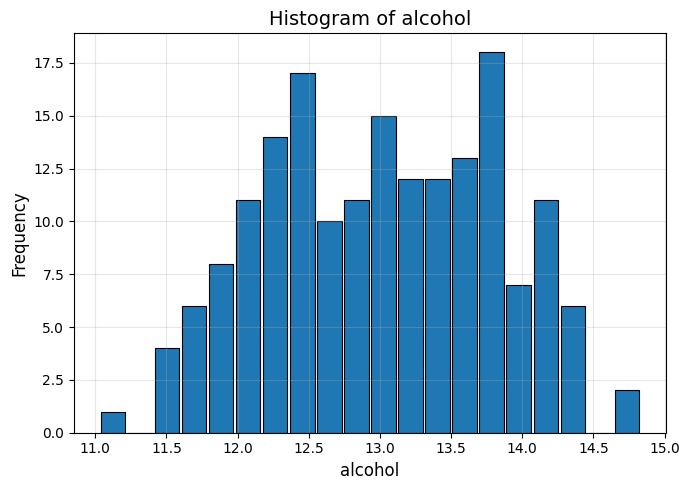

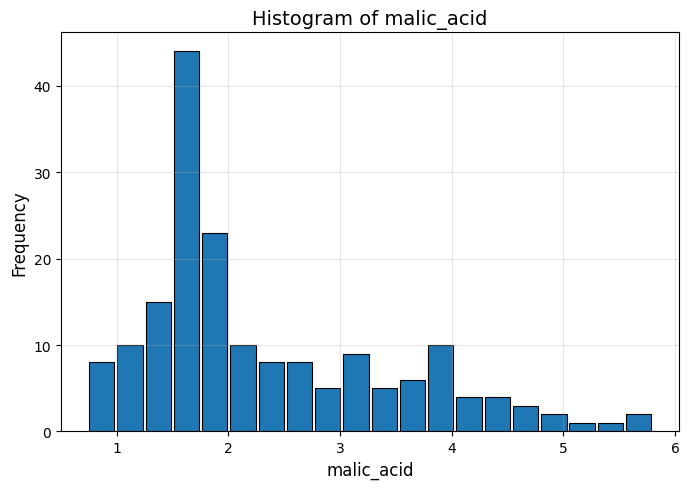

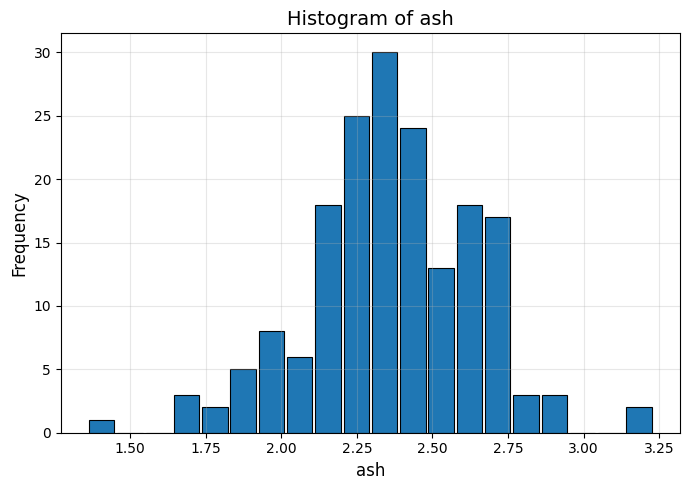

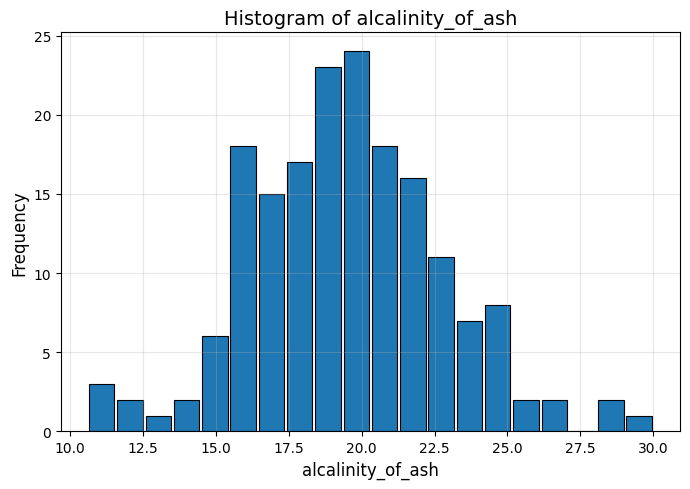

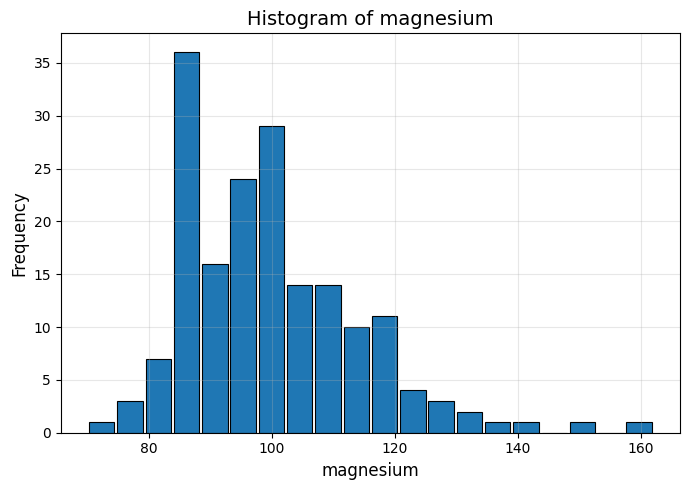

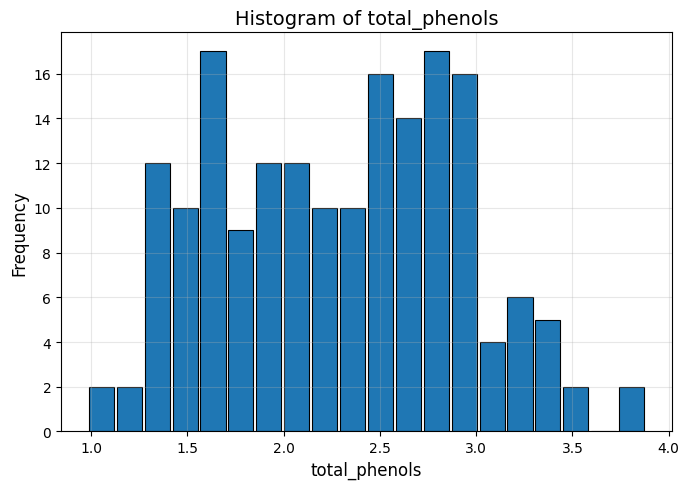

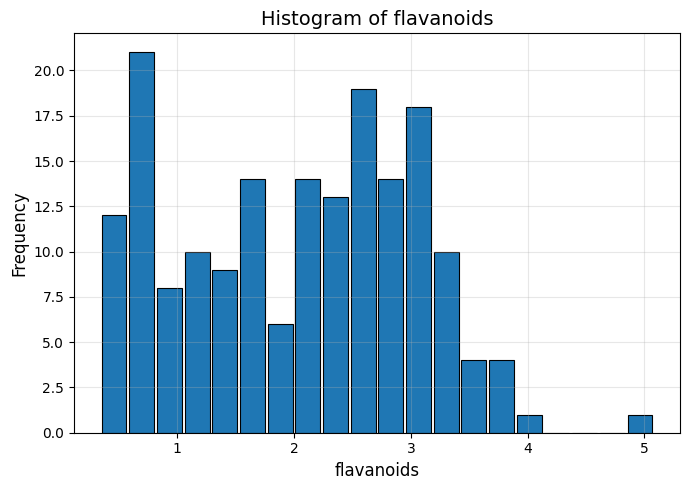

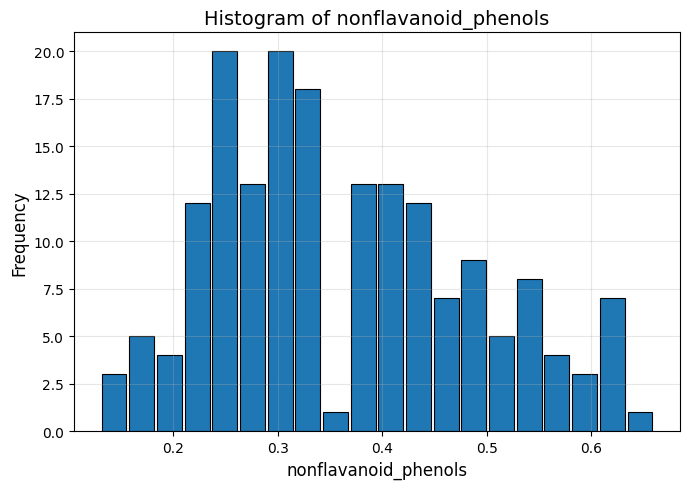

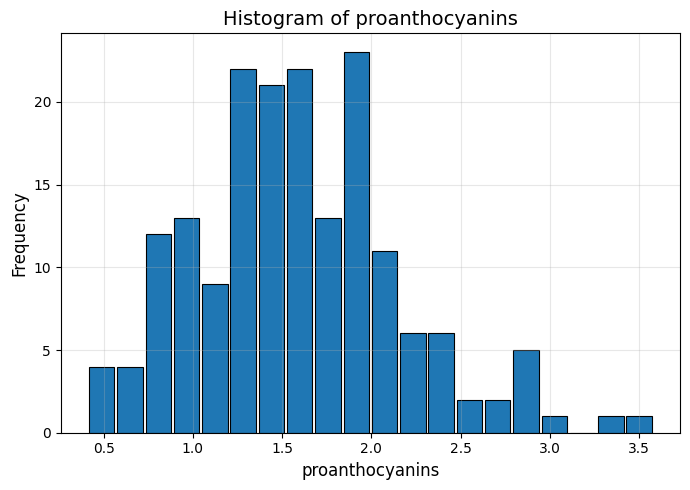

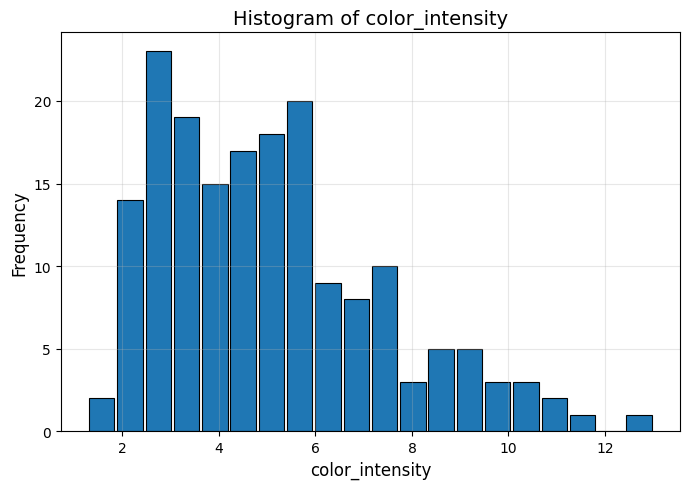

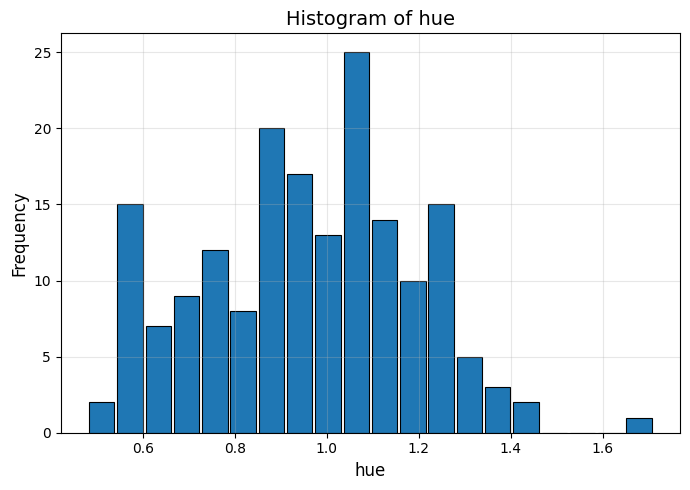

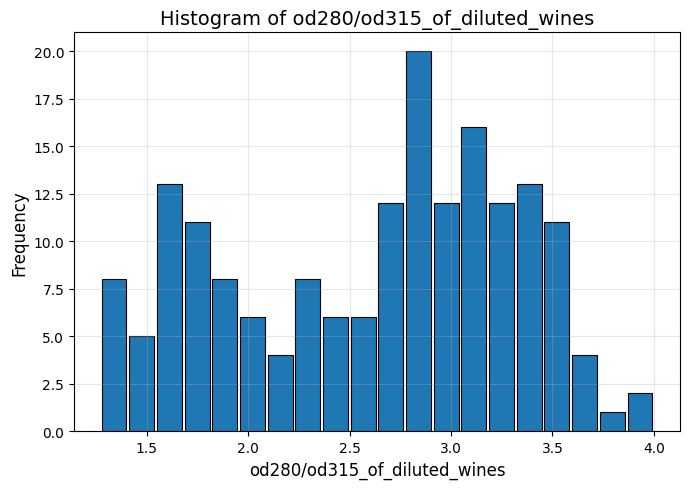

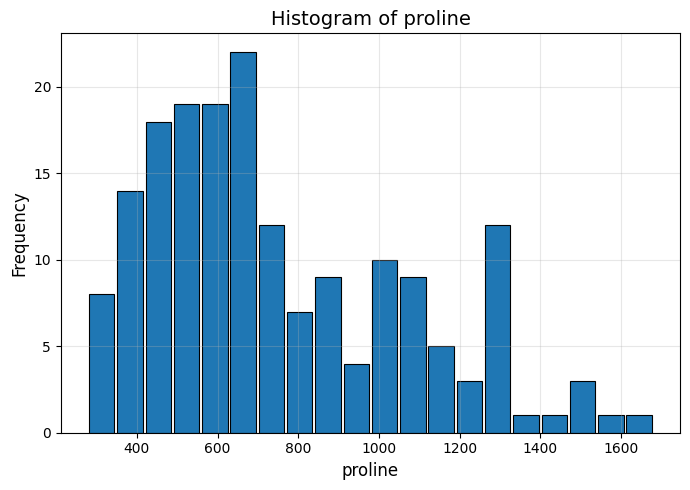

In [ ]:
# 7
for feature in feature_names:
    
    fig, ax = plt.subplots(figsize=(7,5))
    
    ax.hist(
        df[feature],
        bins=20,
        edgecolor="black",
        linewidth=0.8,
        rwidth=0.9
    )
    
    ax.set_title(f"Histogram of {feature}", fontsize=14)
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    
    # save_plot(fig, f"hist_{feature}.png", directory="histograms")
    
    plt.show()

## Correlation Matrix (Heatmap)

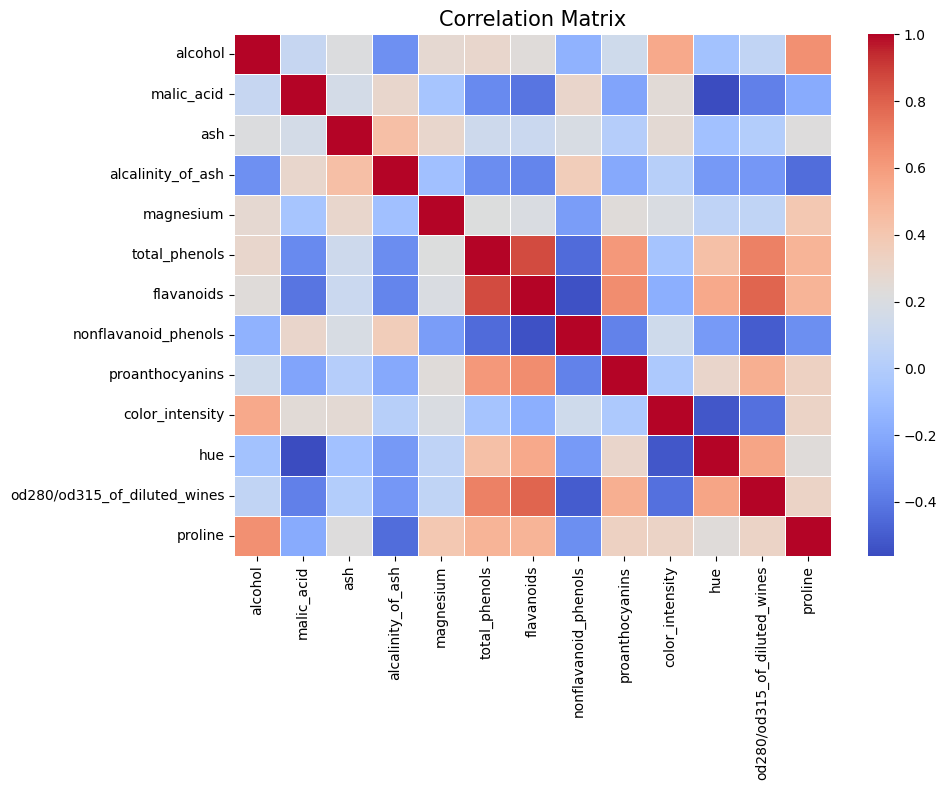

In [ ]:
# 8
corr = df.corr()

fig, ax = plt.subplots(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5,
    linecolor="white",
    ax=ax
)

ax.set_title("Correlation Matrix", fontsize=15)

plt.tight_layout()

save_plot(fig, "correlation_heatmap.png", directory="plots/heatmap")

plt.show()

plt.close(fig)

## Scatter Plots of Highly Correlated Features

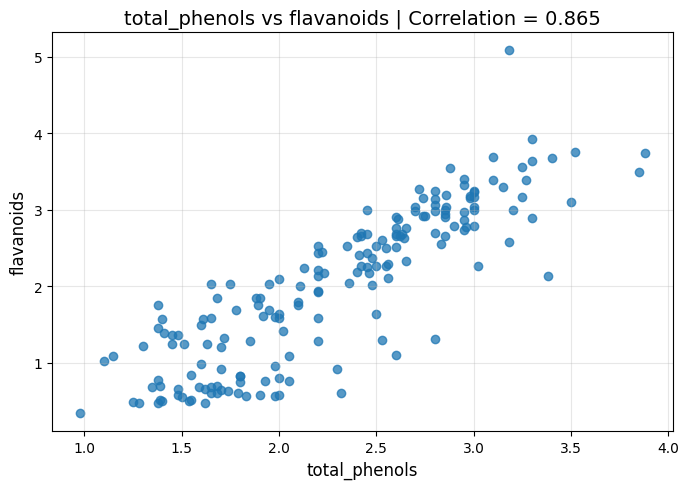

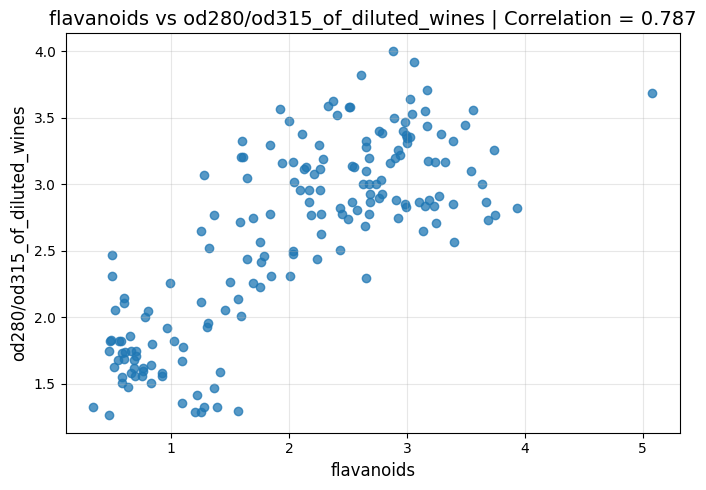

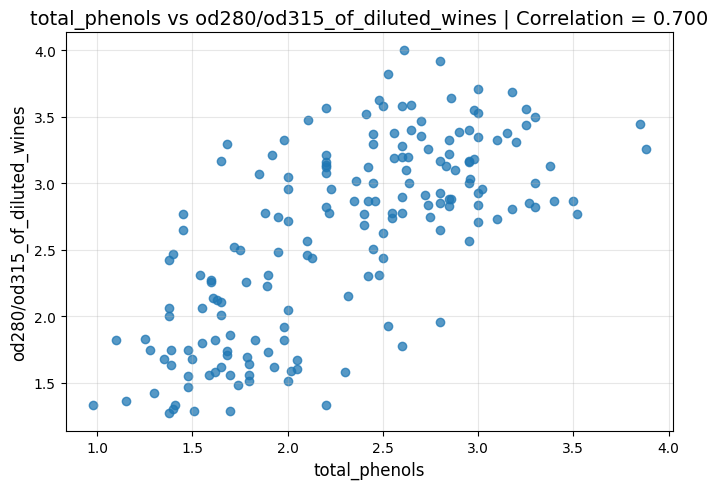

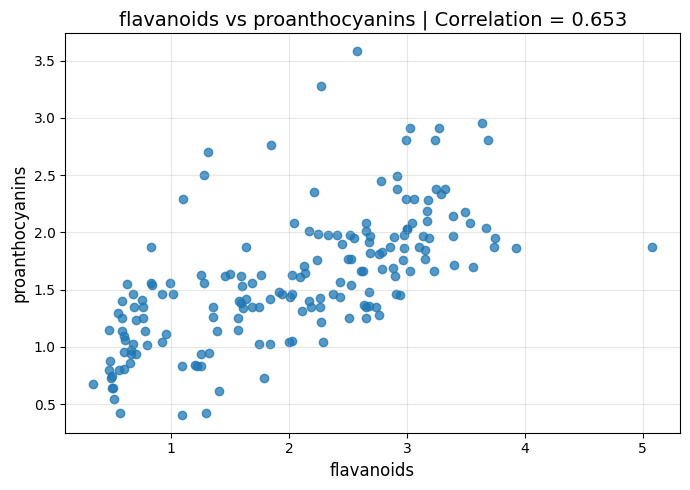

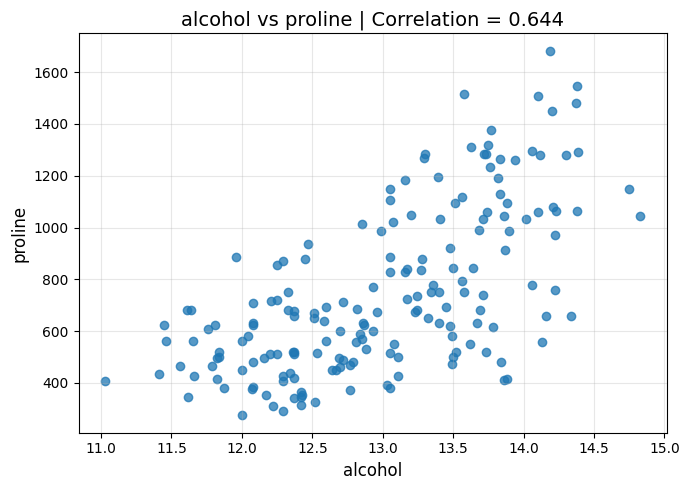

In [ ]:
# 9
import numpy as np

corr_matrix = df.corr()

pairs = []

for i in range(len(feature_names)):
    for j in range(i+1, len(feature_names)):
        f1 = feature_names[i]
        f2 = feature_names[j]
        corr_value = corr_matrix.loc[f1, f2]
        pairs.append((f1, f2, corr_value, abs(corr_value)))

pairs_sorted = sorted(pairs, key=lambda x: x[3], reverse=True)

top_k = 5
selected_pairs = pairs_sorted[:top_k]

for f1, f2, corr_value, _ in selected_pairs:
    
    fig, ax = plt.subplots(figsize=(7,5))
    
    ax.scatter(
        df[f1],
        df[f2],
        alpha=0.75
    )
    
    ax.set_title(
        f"{f1} vs {f2} | Correlation = {corr_value:.3f}",
        fontsize=14
    )
    ax.set_xlabel(f1, fontsize=12)
    ax.set_ylabel(f2, fontsize=12)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    
    # save_plot(fig, f"scatter_{f1}_{f2}.png", directory="scatterplots")
    
    plt.show()

## PCA for Visualization

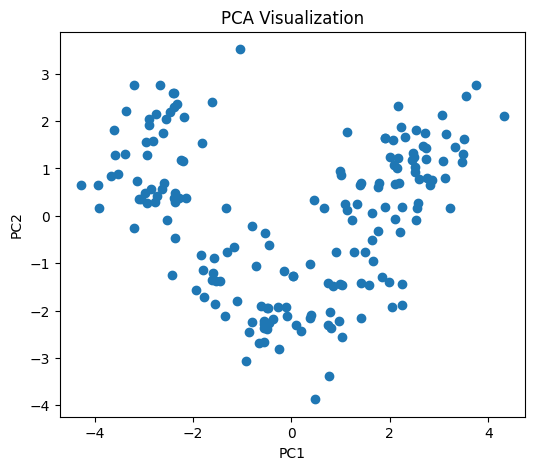

In [ ]:
# 10
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")
plt.show()

## Distance Behavior in High-Dimensional Space

In [ ]:
# 11
def distance_statistics(X, metric):
    D = pairwise_distances(X, metric=metric)
    upper = D[np.triu_indices_from(D, k=1)]
    return np.mean(upper), np.std(upper), np.min(upper), np.max(upper)

metrics = ["euclidean", "manhattan", "cosine"]

results = []
for m in metrics:
    stats = distance_statistics(X_std, m)
    results.append([m] + list(stats))

dist_df = pd.DataFrame(results, columns=["Metric","Mean","Std","Min","Max"])
dist_df

,Metric,Mean,Std,Min,Max
0,euclidean,4.906290,1.440558,1.164114,11.211496
1,manhattan,14.631065,4.705800,3.195960,32.001170
2,cosine,1.003779,0.436736,0.045085,1.918261


## Impact of Feature Scaling on K-Means

K-Means clustering (k = 3) is applied to raw, standardized,
and min-max scaled datasets.
Inertia and silhouette score are computed for comparison.

In [ ]:
# 12
def evaluate_kmeans(X):
    model = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    inertia = model.inertia_
    sil = silhouette_score(X, labels)
    return inertia, sil

datasets = {
    "Raw": X_raw,
    "Standardized": X_std,
    "MinMax": X_mm
}

kmeans_results = []

for name, data in datasets.items():
    inertia, sil = evaluate_kmeans(data)
    kmeans_results.append([name, inertia, sil])

kmeans_df = pd.DataFrame(kmeans_results, columns=["Data","Inertia","Silhouette"])
kmeans_df

,Data,Inertia,Silhouette
0,Raw,2.370690e+06,0.571138
1,Standardized,1.277928e+03,0.284859
2,MinMax,4.896052e+01,0.300894


## K-Means Implementation

In [ ]:
# 13
class CustomKMeans:
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        
    def fit(self, X):
        np.random.seed(self.random_state)
        idx = np.random.choice(len(X), self.n_clusters, replace=False)
        self.centroids = X[idx]
        
        for i in range(self.max_iter):
            distances = pairwise_distances(X, self.centroids)
            labels = np.argmin(distances, axis=1)
            
            new_centroids = []
            
            for k in range(self.n_clusters):
                cluster_points = X[labels == k]
                
                if len(cluster_points) == 0:
                    new_centroids.append(
                        X[np.random.randint(0, len(X))]
                    )
                else:
                    new_centroids.append(cluster_points.mean(axis=0))
            
            new_centroids = np.array(new_centroids)
            
            if np.linalg.norm(new_centroids - self.centroids) < self.tol:
                break
                
            self.centroids = new_centroids
        
        self.labels_ = labels
        self.n_iter_ = i+1
        self.inertia_ = np.sum((X - self.centroids[labels])**2)
        
        return self

## Comparison with scikit-learn Implementation

In [ ]:
# 14
start = time.time()
custom = CustomKMeans().fit(X_std)
t1 = time.time() - start

start = time.time()
sk_model = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_std)
t2 = time.time() - start

compare_df = pd.DataFrame({
    "Model":["Custom","Sklearn"],
    "Inertia":[custom.inertia_, sk_model.inertia_],
    "Iterations":[custom.n_iter_, sk_model.n_iter_],
    "Runtime":[t1, t2]
})

compare_df

,Model,Inertia,Iterations,Runtime
0,Custom,1277.928489,10,0.010703
1,Sklearn,1277.928489,7,0.035742


## Hierarchical Clustering Stability Analysis

In [ ]:
# 15
linkages = ["single","complete","average","ward"]

coph_results = []

for l in linkages:
    Z = linkage(X_std, method=l)
    coph_corr, _ = cophenet(Z, pdist(X_std))
    coph_results.append([l, coph_corr])

coph_df = pd.DataFrame(coph_results, columns=["Linkage","CopheneticCorrelation"])
coph_df = coph_df.sort_values("CopheneticCorrelation", ascending=False)

coph_df

,Linkage,CopheneticCorrelation
2,average,0.759084
3,ward,0.662349
1,complete,0.591683
0,single,0.543623


## Automatic Linkage Selection

In [ ]:
# 16
best_linkage = coph_df.iloc[0]["Linkage"]
print("Best linkage:", best_linkage)

Best linkage: average


## Density-Based Clustering (DBSCAN)

In [ ]:
# 17
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_std)
distances, indices = neighbors_fit.kneighbors(X_std)

k_distances = np.sort(distances[:,4])
epsilon = np.percentile(k_distances, 90)

print("Estimated epsilon:", epsilon)

Estimated epsilon: 3.126881272545291


## DBSCAN Execution

In [ ]:
# 18
db = DBSCAN(eps=epsilon, min_samples=5)
labels_db = db.fit_predict(X_std)

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = list(labels_db).count(-1)

print("Clusters:", n_clusters)
print("Noise points:", n_noise)

Clusters: 1
Noise points: 9


## Alternative Feature Space (If Needed)

If DBSCAN fails to produce meaningful clusters,
the algorithm is re-applied in a reduced PCA feature space.

In [ ]:
# 19
if n_clusters <= 1:
    X_pca2 = PCA(n_components=5, random_state=42).fit_transform(X_std)
    db2 = DBSCAN(eps=epsilon, min_samples=5)
    labels_db2 = db2.fit_predict(X_pca2)
    n_clusters = len(set(labels_db2)) - (1 if -1 in labels_db2 else 0)
    n_noise = list(labels_db2).count(-1)

print("Final clusters:", n_clusters)
print("Final noise:", n_noise)

Final clusters: 1
Final noise: 0


In [ ]:
# 20
if n_clusters > 1:
    db_silhouette = silhouette_score(X_std, labels_db)
    print("DBSCAN Silhouette:", db_silhouette)
else:
    print("Silhouette not computed (single cluster or noise only)")

Silhouette not computed (single cluster or noise only)


## Fully Automated Clustering System

In [ ]:
# 21
def automated_clustering_pipeline(X):
    
    versions = {
        "Standardized": StandardScaler().fit_transform(X),
        "MinMax": MinMaxScaler().fit_transform(X)
    }
    
    best_score = -1
    best_config = None
    
    for name, data in versions.items():
        
        # ----- KMeans Hyperparameter Search -----
        for k in range(2, 7):
            km = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = km.fit_predict(data)
            score = silhouette_score(data, labels)
            
            if score > best_score:
                best_score = score
                best_config = {
                    "Algorithm":"KMeans",
                    "Preprocessing":name,
                    "Parameters":{"k":k},
                    "Score":score
                }
        
        # ----- Hierarchical (best linkage from Part 4) -----
        best_linkage = coph_df.iloc[0]["Linkage"]
        
        for k in range(2, 7):
            model = AgglomerativeClustering(n_clusters=k, linkage=best_linkage)
            labels_h = model.fit_predict(data)
            score_h = silhouette_score(data, labels_h)
            
            if score_h > best_score:
                best_score = score_h
                best_config = {
                    "Algorithm":"Hierarchical",
                    "Preprocessing":name,
                    "Parameters":{"linkage":best_linkage,"k":k},
                    "Score":score_h
                }
        
        # ----- DBSCAN Hyperparameter Search -----
        neighbors = NearestNeighbors(n_neighbors=5)
        distances, _ = neighbors.fit(data).kneighbors(data)
        k_distances = np.sort(distances[:,4])
        
        for perc in [80, 85, 90, 95]:
            eps = np.percentile(k_distances, perc)
            db = DBSCAN(eps=eps, min_samples=5)
            labels_db = db.fit_predict(data)
            
            n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
            
            if n_clusters > 1:
                score_db = silhouette_score(data, labels_db)
                
                if score_db > best_score:
                    best_score = score_db
                    best_config = {
                        "Algorithm":"DBSCAN",
                        "Preprocessing":name,
                        "Parameters":{"eps_percentile":perc,"min_samples":5},
                        "Score":score_db
                    }
    
    return best_config

## Final Selected Configuration

In [ ]:
# 22
final_result = automated_clustering_pipeline(X)
final_result

{'Algorithm': 'KMeans',
 'Preprocessing': 'MinMax',
 'Parameters': {'k': 3},
 'Score': np.float64(0.3008938518500133)}

In [ ]:
# 23
pca_scores = []

for n_comp in range(2, 11):
    pca = PCA(n_components=n_comp, random_state=42)
    X_pca_sub = pca.fit_transform(X_std)
    
    km = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca_sub)
    score = silhouette_score(X_pca_sub, labels)
    
    pca_scores.append([n_comp, score])

pca_df = pd.DataFrame(pca_scores, columns=["Components","Silhouette"])
pca_df.sort_values("Silhouette", ascending=False)

,Components,Silhouette
0,2,0.561051
1,3,0.453235
2,4,0.406597
3,5,0.369076
4,6,0.346257
5,7,0.327635
6,8,0.314970
7,9,0.305783
8,10,0.298675


In [ ]:
# 24
noise_levels = [0.01, 0.05, 0.1]

base_km = KMeans(n_clusters=3, random_state=42, n_init=10)
base_labels = base_km.fit_predict(X_std)

ari_results = []

for sigma in noise_levels:
    
    noise = np.random.normal(0, sigma, X_std.shape)
    X_noisy = X_std + noise
    
    km = KMeans(n_clusters=3, random_state=42, n_init=10)
    noisy_labels = km.fit_predict(X_noisy)
    
    ari = adjusted_rand_score(base_labels, noisy_labels)
    
    ari_results.append([sigma, ari])

ari_df = pd.DataFrame(ari_results, columns=["NoiseStd","ARI"])
ari_df

,NoiseStd,ARI
0,0.01,1.0
1,0.05,1.0
2,0.10,1.0
